## Global Figure Style

Set consistent publication-style formatting:
- Large fonts
- Bold axis labels and titles
- Clean tick formatting
- Higher default DPI

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global matplotlib style
mpl.rcParams.update({

    # Figure
    "figure.dpi": 150,
    "savefig.dpi": 200,

    # Font sizes
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,

    # Bold titles and labels
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",

    # Thicker axes lines
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Better spacing
    "figure.autolayout": False
})

print("Global plotting style set.")

Global plotting style set.


## 1) Configure figure notebook (choose DRUG + which test outputs to plot)

This notebook will now read **saved outputs from 04A/04B** instead of reading an “annotated epistasis table”.

Saved outputs live under:

- `tables/All vs QTL/<DRUG>/`
- `tables/LDpruned vs QTL/<DRUG>/`

We will load both tests into a dictionary (`DATA`) so downstream plotting cells can:
- plot **All vs QTL** figures
- plot **LDpruned vs QTL** figures
- compare them side-by-side (same plotting functions)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================
# EDIT ONLY THIS BLOCK
# =========================
DRUG = "PULV"   # "FLU" or "PULV"

BASE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis")
TABLES = BASE / "tables"

TEST_TYPES = ["All vs QTL", "LDpruned vs QTL"]  # we will load both

# Where figures will be saved
FIG_DIR = BASE / "figures" / DRUG
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("DRUG:", DRUG)
print("FIG_DIR:", FIG_DIR)

# -------------------------
# Helpers to load saved tables
# -------------------------
def load_test_outputs(test_type: str, drug: str) -> dict:
    """
    Loads standardized outputs saved from 04 notebooks.
    Expects:
      - epi_clean.tsv
      - interval_summary.tsv
      - (optional) modifier_locus_summary.tsv
      - (optional) sign_summary.tsv
    """
    d = TABLES / test_type / drug
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

    out = {}
    out["dir"] = d
    out["epi_clean"] = pd.read_csv(d / "epi_clean.tsv", sep="\t")
    out["interval_summary"] = pd.read_csv(d / "interval_summary.tsv", sep="\t")

    # Optional files (may or may not exist depending on how far the notebook went)
    p_locus = d / "modifier_locus_summary.tsv"
    p_sign  = d / "sign_summary.tsv"
    out["modifier_locus_summary"] = pd.read_csv(p_locus, sep="\t") if p_locus.exists() else None
    out["sign_summary"] = pd.read_csv(p_sign, sep="\t") if p_sign.exists() else None

    return out

# -------------------------
# Load both tests for this DRUG
# -------------------------
DATA = {}
for tt in TEST_TYPES:
    DATA[tt] = load_test_outputs(tt, DRUG)
    print(f"\nLoaded: {tt}")
    print(" - epi_clean:", DATA[tt]["epi_clean"].shape)
    print(" - interval_summary:", DATA[tt]["interval_summary"].shape)
    print(" - modifier_locus_summary:", None if DATA[tt]["modifier_locus_summary"] is None else DATA[tt]["modifier_locus_summary"].shape)
    print(" - sign_summary:", None if DATA[tt]["sign_summary"] is None else DATA[tt]["sign_summary"].shape)

DRUG: PULV
FIG_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/PULV

Loaded: All vs QTL
 - epi_clean: (321200, 13)
 - interval_summary: (4, 6)
 - modifier_locus_summary: (16, 4)
 - sign_summary: None

Loaded: LDpruned vs QTL
 - epi_clean: (11180, 12)
 - interval_summary: (4, 4)
 - modifier_locus_summary: (7, 4)
 - sign_summary: (4, 6)


## 2) Quick QC: confirm required columns + harmonize schema across tests

Our saved `epi_clean.tsv` tables differ slightly between:
- **All vs QTL** (13 columns)
- **LDpruned vs QTL** (12 columns)

Before plotting, we standardize a common minimal schema:
- `QTL_SNP`
- `MOD_SNP`
- `BETA_INT`
- `P`

If `QTL_SNP` / `MOD_SNP` are missing (older saves), we reconstruct them from `SNP1/SNP2`
using a QTL SNP set (but for your current PULV outputs, you already have these columns).

In [3]:
# --- QC + standardize epi_clean schema ---

REQUIRED = {"BETA_INT", "P"}

def ensure_schema(df: pd.DataFrame, test_type: str) -> pd.DataFrame:
    df = df.copy()

    # Basic required cols
    missing = REQUIRED - set(df.columns)
    if missing:
        raise ValueError(f"[{test_type}] epi_clean missing required columns: {missing}. Columns={list(df.columns)}")

    # Ensure QTL_SNP / MOD_SNP exist; if not, we can reconstruct later (but prefer to have them)
    if "QTL_SNP" not in df.columns or "MOD_SNP" not in df.columns:
        # fallback: if SNP1/SNP2 exist but QTL_SNP/MOD_SNP don't, we keep for now and reconstruct later
        have_pair = {"SNP1", "SNP2"}.issubset(df.columns)
        if not have_pair:
            raise ValueError(
                f"[{test_type}] epi_clean missing QTL_SNP/MOD_SNP and also missing SNP1/SNP2. "
                f"Columns={list(df.columns)}"
            )

    # Ensure numeric types
    df["BETA_INT"] = pd.to_numeric(df["BETA_INT"], errors="coerce")
    df["P"] = pd.to_numeric(df["P"], errors="coerce")

    # Drop any bad rows (should be none)
    df = df.dropna(subset=["BETA_INT", "P"])

    return df

for tt in TEST_TYPES:
    DATA[tt]["epi_clean"] = ensure_schema(DATA[tt]["epi_clean"], tt)
    print(tt, "-> epi_clean OK. shape:", DATA[tt]["epi_clean"].shape, "cols:", len(DATA[tt]["epi_clean"].columns))

# Quick preview of columns
for tt in TEST_TYPES:
    print("\n", tt, "columns:\n", list(DATA[tt]["epi_clean"].columns))

All vs QTL -> epi_clean OK. shape: (321200, 13) cols: 13
LDpruned vs QTL -> epi_clean OK. shape: (11180, 12) cols: 12

 All vs QTL columns:
 ['CHR1', 'SNP1', 'CHR2', 'SNP2', 'BETA_INT', 'STAT', 'P', 'SNP1_is_qtl', 'SNP2_is_qtl', 'QTL_SNP', 'MOD_SNP', 'MOD_LOCUS', 'MOD_LOCUS_REFINED']

 LDpruned vs QTL columns:
 ['CHR1', 'SNP1', 'CHR2', 'SNP2', 'BETA_INT', 'STAT', 'P', 'SNP1_is_qtl', 'SNP2_is_qtl', 'QTL_SNP', 'MOD_SNP', 'MOD_LOCUS_ID']


## 3) Load SNP genomic positions (for Manhattan-style modifier plots)

We now load the SNP annotation table used in PLINK.

We only need:
- SNP ID
- Chromosome
- Position (bp)

This will allow us to:
- Compute per-modifier interaction burden
- Plot modifier hotspots across chromosomes

In [4]:
# ---- Load SNP annotation ----

SNP_INFO_PATH = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/snp_info_complete.tsv"

snp_info = pd.read_csv(SNP_INFO_PATH, sep="\t")

required_cols = {"SNP", "Chromosome", "Position (bp)"}
missing = required_cols - set(snp_info.columns)
if missing:
    raise ValueError(f"snp_info missing columns: {missing}")

snp_info = snp_info[["SNP", "Chromosome", "Position (bp)"]].copy()
snp_info["Chromosome"] = snp_info["Chromosome"].astype(int)
snp_info["Position (bp)"] = snp_info["Position (bp)"].astype(int)

print("SNP info loaded:", snp_info.shape)
snp_info.head()

SNP info loaded: (41594, 3)


,SNP,Chromosome,Position (bp)
0,snp1,1,27210
1,snp2,1,27290
2,snp3,1,27356
3,snp4,1,27357
4,snp5,1,27370


## 4) Compute modifier interaction burden (for Manhattan-style plots)

For each test, we summarize modifiers by:
- `n_interactions`: how many significant QTL×modifier pairs involve the modifier SNP
- `min_p`: strongest interaction P-value involving that modifier
- `max_abs_beta`: strongest |β_int| involving that modifier

Then we merge genomic position so we can make Manhattan-style plots.

In [5]:
def summarize_modifiers(epi_clean: pd.DataFrame) -> pd.DataFrame:
    out = (
        epi_clean
        .groupby("MOD_SNP")
        .agg(
            n_interactions=("P", "count"),
            min_p=("P", "min"),
            max_abs_beta=("BETA_INT", lambda x: x.abs().max())
        )
        .reset_index()
        .rename(columns={"MOD_SNP": "SNP"})
    )
    return out

MOD = {}
for tt in TEST_TYPES:
    mod = summarize_modifiers(DATA[tt]["epi_clean"])
    mod = mod.merge(snp_info, on="SNP", how="left")

    # sanity: ensure positions exist
    if mod["Chromosome"].isna().any():
        missing = mod.loc[mod["Chromosome"].isna(), "SNP"].head(10).tolist()
        raise ValueError(f"[{tt}] Some modifier SNPs missing in snp_info. Example: {missing}")

    mod["Chromosome"] = mod["Chromosome"].astype(int)
    mod["Position (bp)"] = mod["Position (bp)"].astype(int)
    mod["neglog10_minp"] = -np.log10(mod["min_p"])

    MOD[tt] = mod.sort_values(["Chromosome", "Position (bp)"]).reset_index(drop=True)

    print(f"{tt}: modifiers summarized ->", MOD[tt].shape)
    print("  top rows:")
    display(MOD[tt].sort_values(["n_interactions","min_p"], ascending=[False, True]).head(5))

All vs QTL: modifiers summarized -> (4928, 7)
  top rows:


,SNP,n_interactions,min_p,max_abs_beta,Chromosome,Position (bp),neglog10_minp
2707,snp34754,191,1.280000e-29,0.018132,14,487930,28.892790
2706,snp34753,189,1.599000e-29,0.018063,14,487813,28.796152
2708,snp34755,181,2.309000e-29,0.017969,14,488593,28.636576
2702,snp34749,158,1.475000e-29,0.018571,14,484899,28.831208
2705,snp34752,131,4.495000e-29,0.017718,14,487245,28.347270


LDpruned vs QTL: modifiers summarized -> (162, 7)
  top rows:


,SNP,n_interactions,min_p,max_abs_beta,Chromosome,Position (bp),neglog10_minp
105,snp34749,458,1.475000e-29,0.018571,14,484899,28.831208
104,snp34745,257,9.999000e-31,0.019578,14,478696,30.000043
31,snp14467,127,3.436000e-126,0.032397,7,479589,125.463947
30,snp14409,127,1.228000e-122,0.031940,7,465447,121.910802
32,snp14623,127,3.256000e-109,0.030293,7,509101,108.487316


## 5) Configure Figure Output Directories

Figures will be saved to:

- All vs QTL → /blue/.../5_epistasis/All vs QTL/<DRUG>/
- LDpruned vs QTL → /blue/.../5_epistasis/LDpruned vs QTL/<DRUG>/

Each figure will be saved as:
- PNG (high resolution)
- PDF (vector format)

All plots will also be displayed inline using plt.show().

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG_OUT = {
    "All vs QTL": BASE / "figures" / "All vs QTL" / DRUG,
    "LDpruned vs QTL": BASE / "figures" / "LDpruned vs QTL" / DRUG,
}

for name, path in FIG_OUT.items():
    path.mkdir(parents=True, exist_ok=True)
    print(name, "->", path)

def savefig(out_dir, stem: str, dpi: int = 300):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    fig = plt.gcf()
    # Use ONE layout strategy: manual margins (robust for big/bold fonts)
    fig.subplots_adjust(left=0.08, right=0.995, bottom=0.20, top=0.88)

    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"

    fig.savefig(png, dpi=dpi, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.15)

    print("Saved:", png)
    print("Saved:", pdf)

All vs QTL -> /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV
LDpruned vs QTL -> /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV


## 6) Helper: Build Genome-wide X-axis

We convert chromosome + position into a cumulative genome coordinate,
so we can draw Manhattan-style plots across the whole genome.

In [7]:
import numpy as np

def add_genome_x(df, chr_col="Chromosome", pos_col="Position (bp)"):
    df = df.copy()

    chr_max = snp_info.groupby("Chromosome")["Position (bp)"].max().sort_index()
    chroms = chr_max.index.tolist()

    offsets = {}
    cumulative = 0
    for c in chroms:
        offsets[c] = cumulative
        cumulative += int(chr_max.loc[c]) + 1

    df["x"] = df[chr_col].map(offsets) + df[pos_col]

    mids = []
    labels = []
    for c in chroms:
        start = offsets[c]
        end = offsets[c] + int(chr_max.loc[c])
        mids.append((start + end) / 2)
        labels.append(str(c))

    return df, mids, labels

## 7) Figure 1 — Modifier Interaction Burden (Manhattan Style)

Y-axis:
Number of significant QTL×modifier interactions per modifier SNP.

This identifies modifier "hotspots".

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig1_modifier_manhattan_n_interactions.png (0.13 MB)
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig1_modifier_manhattan_n_interactions.pdf (0.04 MB)


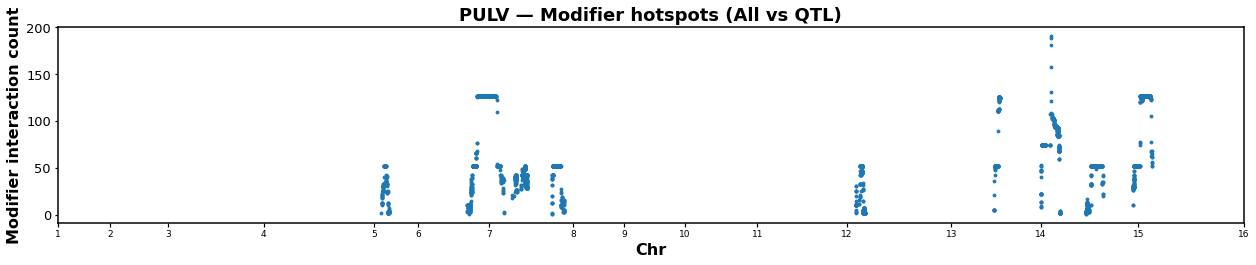


Contents: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV
['fig1_modifier_manhattan_n_interactions.pdf', 'fig1_modifier_manhattan_n_interactions.png']
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig1_modifier_manhattan_n_interactions.png (0.11 MB)
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig1_modifier_manhattan_n_interactions.pdf (0.02 MB)


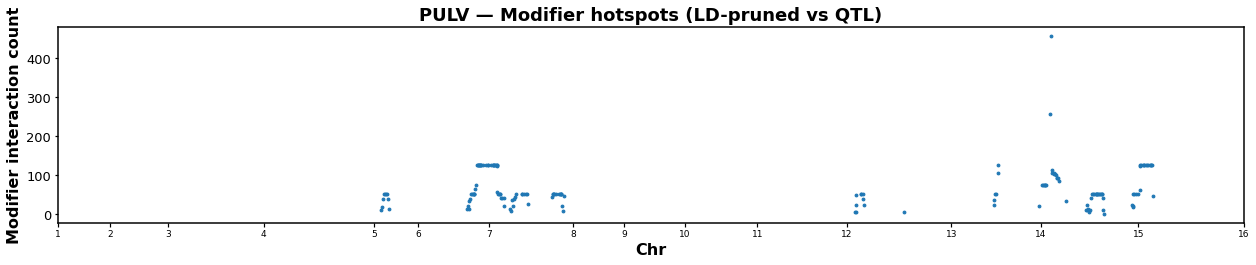


Contents: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV
['.ipynb_checkpoints', 'fig1_modifier_manhattan_n_interactions.pdf', 'fig1_modifier_manhattan_n_interactions.png']


In [8]:
from pathlib import Path

def plot_modifier_manhattan_save(mod_df, title, out_dir, stem):
    df, mids, labels = add_genome_x(mod_df)

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.scatter(df["x"], df["n_interactions"], s=8)

    ax.set_xticks(mids)
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_xlabel("Chr")
    ax.set_ylabel("Modifier interaction count")
    ax.set_title(title)

    fig.subplots_adjust(left=0.08, right=0.995, bottom=0.20, top=0.88)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"

    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.15)

    print("Saved:", png, f"({png.stat().st_size/1e6:.2f} MB)")
    print("Saved:", pdf, f"({pdf.stat().st_size/1e6:.2f} MB)")

    plt.show()

# --- Figure 1A: All vs QTL ---
plot_modifier_manhattan_save(
    MOD["All vs QTL"],
    f"{DRUG} — Modifier hotspots (All vs QTL)",
    FIG_OUT["All vs QTL"],
    "fig1_modifier_manhattan_n_interactions"
)

print("\nContents:", FIG_OUT["All vs QTL"])
print([p.name for p in sorted(Path(FIG_OUT["All vs QTL"]).glob("*"))])

# --- Figure 1B: LDpruned vs QTL ---
plot_modifier_manhattan_save(
    MOD["LDpruned vs QTL"],
    f"{DRUG} — Modifier hotspots (LD-pruned vs QTL)",
    FIG_OUT["LDpruned vs QTL"],
    "fig1_modifier_manhattan_n_interactions"
)

print("\nContents:", FIG_OUT["LDpruned vs QTL"])
print([p.name for p in sorted(Path(FIG_OUT["LDpruned vs QTL"]).glob("*"))])

## 8) Figure 2 — Modifier strength (−log10(min P)) Manhattan-style

Figure 1 showed **burden** (# interactions per modifier).  
Figure 2 shows **strength**: for each modifier SNP, we plot the strongest interaction it participates in:

- `min_p` = minimum P-value across all interactions involving that modifier SNP  
- `−log10(min_p)` = stronger signal → larger value

We generate:
- Figure 2A: All vs QTL
- Figure 2B: LDpruned vs QTL
and save them under:
- figures/All vs QTL/<DRUG>/
- figures/LDpruned vs QTL/<DRUG>/

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig2_modifier_manhattan_neglog10_minp.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig2_modifier_manhattan_neglog10_minp.pdf


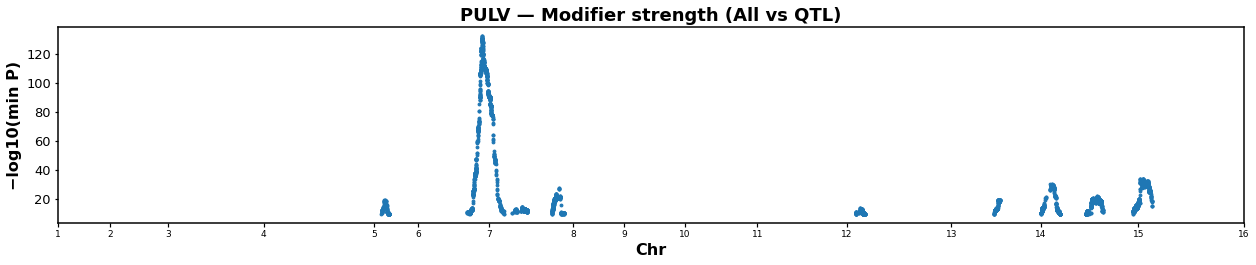

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig2_modifier_manhattan_neglog10_minp.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig2_modifier_manhattan_neglog10_minp.pdf


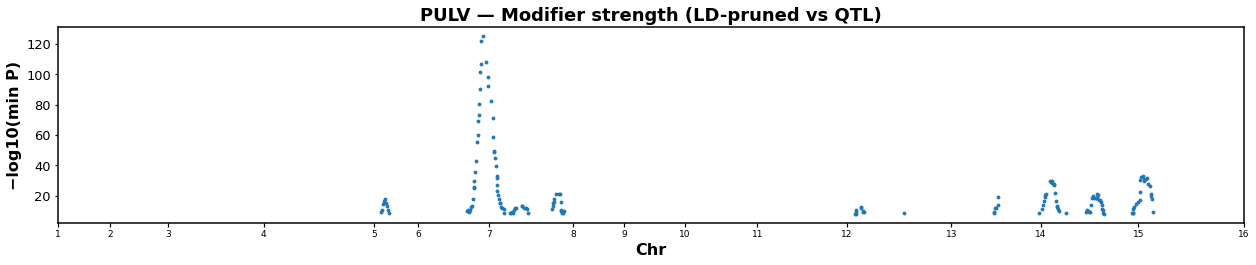

In [9]:
def plot_modifier_strength_save(mod_df, title, out_dir, stem):
    # mod_df must contain: Chromosome, Position (bp), neglog10_minp
    df, mids, labels = add_genome_x(mod_df)

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.scatter(df["x"], df["neglog10_minp"], s=8)

    ax.set_xticks(mids)
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_xlabel("Chr")
    ax.set_ylabel("−log10(min P)")
    ax.set_title(title)

    fig.subplots_adjust(left=0.08, right=0.995, bottom=0.20, top=0.88)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"

    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.15)

    print("Saved:", png)
    print("Saved:", pdf)

    plt.show()


# --- Figure 2A: All vs QTL ---
plot_modifier_strength_save(
    MOD["All vs QTL"],
    f"{DRUG} — Modifier strength (All vs QTL)",
    FIG_OUT["All vs QTL"],
    "fig2_modifier_manhattan_neglog10_minp"
)

# --- Figure 2B: LDpruned vs QTL ---
plot_modifier_strength_save(
    MOD["LDpruned vs QTL"],
    f"{DRUG} — Modifier strength (LD-pruned vs QTL)",
    FIG_OUT["LDpruned vs QTL"],
    "fig2_modifier_manhattan_neglog10_minp"
)

## 9) Figure 3 — Interval-level epistasis burden (by QTL interval)

Now we move from SNP-level views (Figures 1–2) to **QTL-interval summaries**.

`interval_summary.tsv` (saved from 04 notebooks) aggregates epistasis signal per interval.
Because the schema differs slightly between tests, we standardize to these columns when available:

- `interval_id`
- `n_interactions`
- `min_p`
- `max_abs_beta` (if present)

We will make a clean bar plot of **n_interactions per interval** for:
- Figure 3A: All vs QTL
- Figure 3B: LDpruned vs QTL

In [10]:
def standardize_interval_summary(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Some versions may already have interval_id as index; enforce a column
    if "interval_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "interval_id"})

    # Standard names if different
    rename_map = {}
    if "n_interactions" not in df.columns and "n_interactions" in df.index.names:
        df = df.reset_index()

    # Coerce types
    df["interval_id"] = pd.to_numeric(df["interval_id"], errors="coerce").astype("Int64")

    # Ensure n_interactions exists
    if "n_interactions" not in df.columns:
        # common fallback: if someone saved as "total" etc.
        candidates = [c for c in df.columns if c.lower() in {"n_interactions", "n_sig", "count", "total"}]
        raise ValueError(f"interval_summary missing n_interactions. Columns={list(df.columns)} candidates={candidates}")

    df["n_interactions"] = pd.to_numeric(df["n_interactions"], errors="coerce")

    # Optional cols
    if "min_p" in df.columns:
        df["min_p"] = pd.to_numeric(df["min_p"], errors="coerce")
    if "max_abs_beta" in df.columns:
        df["max_abs_beta"] = pd.to_numeric(df["max_abs_beta"], errors="coerce")
    if "max_beta" in df.columns and "max_abs_beta" not in df.columns:
        df["max_abs_beta"] = pd.to_numeric(df["max_beta"], errors="coerce")

    df = df.dropna(subset=["interval_id", "n_interactions"])
    df = df.sort_values("n_interactions", ascending=False)

    return df

INT = {}
for tt in TEST_TYPES:
    INT[tt] = standardize_interval_summary(DATA[tt]["interval_summary"])
    print(tt, "interval_summary standardized:", INT[tt].shape)
    display(INT[tt])

All vs QTL interval_summary standardized: (4, 7)


,interval_id,n_interactions,n_unique_qtl_snps,n_unique_mod_snps,min_p,max_beta,max_abs_beta
0,34738,199866,52,4710,4.622000e-133,0.033153,0.033153
1,16910,121009,75,1687,6.230000e-34,0.017595,0.017595
2,37622,324,94,6,3.552000e-11,0.008984,0.008984
3,15201,1,1,1,3.831000e-10,0.008648,0.008648


LDpruned vs QTL interval_summary standardized: (4, 4)


,interval_id,n_interactions,min_p,max_abs_beta
0,34738,6421,3.436000e-126,0.032397
1,16910,4272,5.036000e-32,0.017595
2,37622,446,1.359000e-10,0.008784
3,15201,41,5.168000e-10,0.008721


Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig3_interval_burden_n_interactions.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig3_interval_burden_n_interactions.pdf


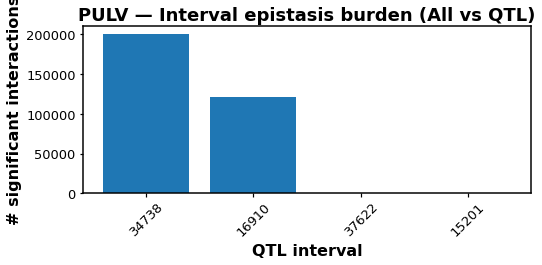

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig3_interval_burden_n_interactions.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig3_interval_burden_n_interactions.pdf


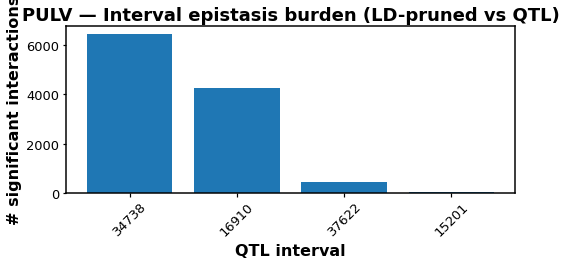

In [11]:
def plot_interval_burden_save(interval_df: pd.DataFrame, title: str, out_dir: Path, stem: str):
    df = interval_df.copy().sort_values("n_interactions", ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(df["interval_id"].astype(str), df["n_interactions"])

    ax.set_xlabel("QTL interval")
    ax.set_ylabel("# significant interactions")
    ax.set_title(title)

    # make x labels readable
    ax.tick_params(axis="x", labelrotation=45)

    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.30, top=0.88)

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.15)

    print("Saved:", png)
    print("Saved:", pdf)

    plt.show()

# --- Figure 3A: All vs QTL ---
plot_interval_burden_save(
    INT["All vs QTL"],
    f"{DRUG} — Interval epistasis burden (All vs QTL)",
    FIG_OUT["All vs QTL"],
    "fig3_interval_burden_n_interactions"
)

# --- Figure 3B: LDpruned vs QTL ---
plot_interval_burden_save(
    INT["LDpruned vs QTL"],
    f"{DRUG} — Interval epistasis burden (LD-pruned vs QTL)",
    FIG_OUT["LDpruned vs QTL"],
    "fig3_interval_burden_n_interactions"
)

## 10) Figure 4 — Interval sign bias (positive vs negative epistasis)

For LDpruned vs QTL, you already saved `sign_summary.tsv`, which contains (per interval):
- number of negative interactions
- number of positive interactions
- fraction positive / fraction negative

This figure makes the biological interpretation easier:
- intervals dominated by **positive** interactions vs
- intervals dominated by **negative** interactions

We will:
- plot stacked bars (negative + positive) per interval
- also plot fraction-positive as a dot overlay (optional)

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig4_interval_sign_bias_stacked.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/LDpruned vs QTL/PULV/fig4_interval_sign_bias_stacked.pdf


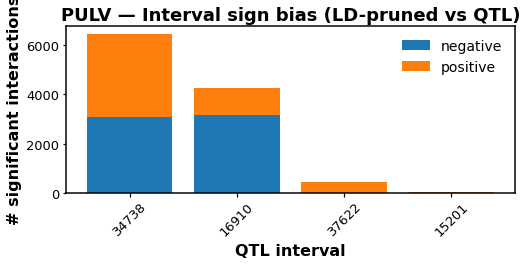

In [12]:
def plot_interval_sign_bias_save(sign_df: pd.DataFrame, title: str, out_dir: Path, stem: str):
    if sign_df is None:
        raise ValueError("sign_summary is None (file not found). Run/sign-save the sign_summary step in 04, or skip this figure.")

    df = sign_df.copy()

    # Standardize column names if needed
    # Expected columns: interval_id, negative, positive, total, frac_positive, frac_negative
    if "interval_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "interval_id"})

    needed = {"negative", "positive"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"sign_summary missing columns: {missing}. Columns={list(df.columns)}")

    df["interval_id"] = df["interval_id"].astype(str)
    df = df.sort_values("positive", ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(df["interval_id"], df["negative"], label="negative")
    ax.bar(df["interval_id"], df["positive"], bottom=df["negative"], label="positive")

    ax.set_xlabel("QTL interval")
    ax.set_ylabel("# significant interactions")
    ax.set_title(title)
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend(frameon=False)

    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.30, top=0.88)

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.15)

    print("Saved:", png)
    print("Saved:", pdf)

    plt.show()

# Use LDpruned sign_summary if present; otherwise skip
if DATA["LDpruned vs QTL"]["sign_summary"] is not None:
    plot_interval_sign_bias_save(
        DATA["LDpruned vs QTL"]["sign_summary"],
        f"{DRUG} — Interval sign bias (LD-pruned vs QTL)",
        FIG_OUT["LDpruned vs QTL"],
        "fig4_interval_sign_bias_stacked"
    )
else:
    print("No sign_summary.tsv found for LDpruned vs QTL. Skipping Figure 4.")

## 11) Gene-level epistasis plots (3-panel)

Goal: replicate the example figure with:

A) **Gene–gene network**: top N gene–gene edges by significance  
B) **Chromosome-pair heatmap**: interaction counts by (chr(QTL), chr(modifier))  
C) **Top gene–gene pairs barplot**: top K pairs with strongest signal (−log10 P)

Inputs needed:
- `epi_clean` (from DATA[...]["epi_clean"])
- SNP→position (already have `snp_info`)
- Gene table `gene_info.csv` (you loaded earlier; we’ll load it here too)

We’ll do this for one test at a time (choose `"All vs QTL"` or `"LDpruned vs QTL"`).

In [17]:
# =========================
# EDIT ONLY THIS BLOCK
# =========================
TEST_TO_PLOT = "All vs QTL"  # or "All vs QTL" or "LDpruned vs QTL"
P_THRESH = 1e-4                  # to match your example title
TOP_EDGES = 50                   # network edges
TOP_BARS = 15                    # barplot gene-gene pairs
SAVE_STEM = f"fig5_gene_level_{TEST_TO_PLOT.replace(' ','_').replace('/','_')}_pthr_{P_THRESH:g}"

# -------------------------
# Load gene table
# -------------------------
GENE_INFO_PATH = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/gene_info.csv"
gene_info = pd.read_csv(GENE_INFO_PATH)

req = {"gene_name","chrom","gene_chr_start","gene_chr_end","Standard_name"}
missing = req - set(gene_info.columns)
if missing:
    raise ValueError(f"gene_info missing columns: {missing}")

gene_info = gene_info.copy()
gene_info["chrom"] = gene_info["chrom"].astype(int)
gene_info["gene_chr_start"] = gene_info["gene_chr_start"].astype(int)
gene_info["gene_chr_end"] = gene_info["gene_chr_end"].astype(int)

# Use Standard_name when available; fallback to gene_name
gene_info["label"] = gene_info["Standard_name"].fillna("").astype(str).str.strip()
gene_info.loc[gene_info["label"] == "", "label"] = gene_info.loc[gene_info["label"] == "", "gene_name"]

# -------------------------
# Choose epistasis table
# -------------------------
epi = DATA[TEST_TO_PLOT]["epi_clean"].copy()
print("epi_clean:", epi.shape, "cols:", list(epi.columns))

# Filter by P threshold (to match the example)
epi = epi.loc[epi["P"] <= P_THRESH].copy()
print(f"After P <= {P_THRESH:g}:", epi.shape)

# Add -log10P
epi["neglog10P"] = -np.log10(epi["P"])

# Attach positions for QTL + modifier SNPs
pos_cols = ["SNP","Chromosome","Position (bp)"]
epi = epi.merge(
    snp_info[pos_cols].rename(columns={"SNP":"QTL_SNP","Chromosome":"QTL_CHR","Position (bp)":"QTL_POS"}),
    on="QTL_SNP", how="left"
)
epi = epi.merge(
    snp_info[pos_cols].rename(columns={"SNP":"MOD_SNP","Chromosome":"MOD_CHR","Position (bp)":"MOD_POS"}),
    on="MOD_SNP", how="left"
)

if epi["QTL_CHR"].isna().any() or epi["MOD_CHR"].isna().any():
    bad = epi.loc[epi["QTL_CHR"].isna() | epi["MOD_CHR"].isna(), ["QTL_SNP","MOD_SNP"]].head(10)
    raise ValueError(f"Some SNPs missing positions in snp_info. Example:\n{bad}")

epi["QTL_CHR"] = epi["QTL_CHR"].astype(int)
epi["MOD_CHR"] = epi["MOD_CHR"].astype(int)
epi["QTL_POS"] = epi["QTL_POS"].astype(int)
epi["MOD_POS"] = epi["MOD_POS"].astype(int)

print("Position merge OK.")

epi_clean: (321200, 13) cols: ['CHR1', 'SNP1', 'CHR2', 'SNP2', 'BETA_INT', 'STAT', 'P', 'SNP1_is_qtl', 'SNP2_is_qtl', 'QTL_SNP', 'MOD_SNP', 'MOD_LOCUS', 'MOD_LOCUS_REFINED']
After P <= 0.0001: (321200, 13)
Position merge OK.


## 12) Map SNPs → genes and build gene–gene interaction table

We assign:
- QTL_SNP → QTL_GENE (if SNP position lies within a gene interval on that chromosome)
- MOD_SNP → MOD_GENE

Then we collapse interactions to unique gene–gene pairs and keep the strongest signal per pair.
(If a SNP is intergenic, we label it as "Intergenic".)

In [18]:
# --- Helper: map positions to genes (gene bodies only) ---
# Note: simple and readable implementation (fast enough for your ~11k rows)

def map_pos_to_gene(chrom: int, pos: int, gene_df: pd.DataFrame):
    hits = gene_df.loc[
        (gene_df["chrom"] == chrom) &
        (gene_df["gene_chr_start"] <= pos) &
        (gene_df["gene_chr_end"] >= pos),
        "label"
    ]
    if hits.empty:
        return "Intergenic"
    # If multiple overlap (rare), just join unique labels
    return "|".join(sorted(set(hits.tolist())))

# Map QTL and MOD SNPs to genes
epi = epi.copy()

epi["QTL_GENE"] = [
    map_pos_to_gene(c, p, gene_info) for c, p in zip(epi["QTL_CHR"], epi["QTL_POS"])
]
epi["MOD_GENE"] = [
    map_pos_to_gene(c, p, gene_info) for c, p in zip(epi["MOD_CHR"], epi["MOD_POS"])
]

print("QTL_GENE Intergenic fraction:", (epi["QTL_GENE"] == "Intergenic").mean())
print("MOD_GENE Intergenic fraction:", (epi["MOD_GENE"] == "Intergenic").mean())

# Build gene-gene edge table: collapse multiple SNP pairs → strongest signal per gene pair
gg = epi.copy()
gg["GENE_A"] = gg["QTL_GENE"]
gg["GENE_B"] = gg["MOD_GENE"]

# Canonicalize order so A–B and B–A are treated the same (optional; here QTL vs MOD is directional)
# We'll keep directional as in your example: QTL_gene × MOD_gene

gg_edges = (
    gg.groupby(["GENE_A", "GENE_B"], as_index=False)
      .agg(
          n_snp_pairs=("P", "count"),
          min_p=("P", "min"),
          max_neglog10P=("neglog10P", "max"),
          max_abs_beta=("BETA_INT", lambda x: x.abs().max())
      )
      .sort_values(["min_p", "n_snp_pairs"], ascending=[True, False])
)

print("Gene–gene edges:", gg_edges.shape)
gg_edges.head(10)

QTL_GENE Intergenic fraction: 0.4559993773349938
MOD_GENE Intergenic fraction: 0.3723754669987547
Gene–gene edges: (6095, 6)


,GENE_A,GENE_B,n_snp_pairs,min_p,max_neglog10P,max_abs_beta
2271,MKT1,Intergenic,4353,4.622000e-133,132.335170,0.033153
1457,Intergenic,Intergenic,55043,5.060000e-133,132.295849,0.033142
2334,MKT1,PDR1,33,9.407000e-132,131.026549,0.033016
1538,Intergenic,PDR1,704,1.028000e-131,130.988007,0.033005
2230,MKT1,ERG4,12,1.048000e-131,130.979639,0.032999
1411,Intergenic,ERG4,256,1.146000e-131,130.940815,0.032987
4298,SNN1,Intergenic,1420,4.742000e-131,130.324038,0.032886
2412,MKT1,SCL1,18,9.527000e-131,130.021044,0.032916
1625,Intergenic,SCL1,384,1.040000e-130,129.982967,0.032905
4359,SNN1,PDR1,11,9.319000e-130,129.030631,0.032750


## 13) Gene-level epistasis figure (Network + Chr×Chr heatmap + Top pairs)

Panels:

A) Gene–gene interaction network (top edges by min P)  
B) Chromosome-pair interaction heatmap  
C) Top gene–gene pairs (−log10(min P))

We exclude:
- Intergenic–Intergenic edges from the network and barplot
  (otherwise it dominates visually)

All panels are saved to:
figures/<TestType>/<DRUG>/

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_network.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_network.pdf


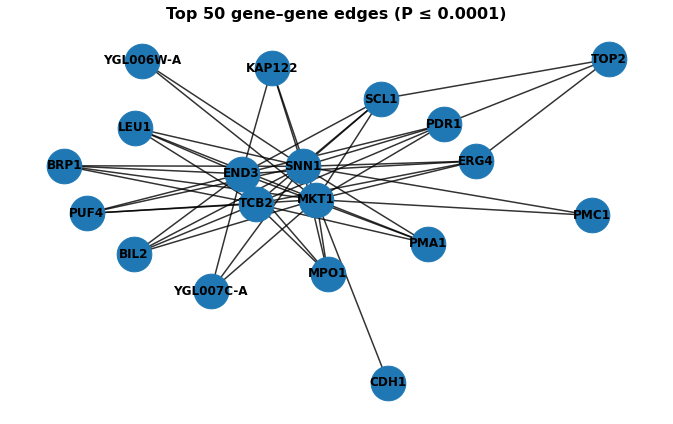

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_chr_heatmap.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_chr_heatmap.pdf


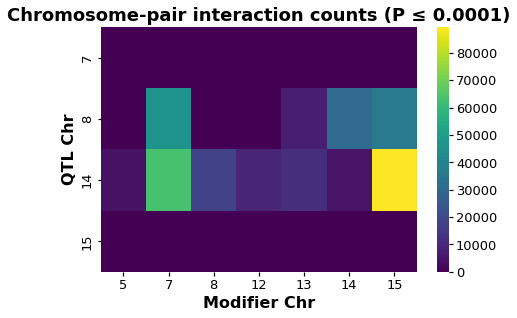

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_top_pairs.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/All vs QTL/PULV/fig5_gene_level_All_vs_QTL_pthr_0.0001_top_pairs.pdf


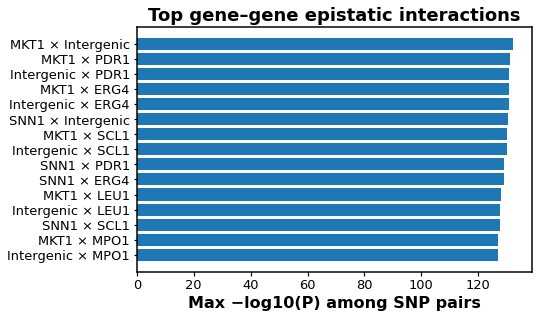

In [19]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Prepare gene-level tables
# =========================

# Remove fully intergenic edges for visualization clarity
gg_plot = gg_edges.loc[
    ~((gg_edges["GENE_A"] == "Intergenic") & 
      (gg_edges["GENE_B"] == "Intergenic"))
].copy()

# Top edges for network
top_edges = gg_plot.sort_values("min_p").head(TOP_EDGES)

# Top gene-gene pairs for barplot
top_bar = gg_plot.sort_values("min_p").head(TOP_BARS)

# =========================
# Panel A — Improved Network
# =========================

# Remove Intergenic nodes entirely for clarity
gg_net = gg_plot.loc[
    (gg_plot["GENE_A"] != "Intergenic") &
    (gg_plot["GENE_B"] != "Intergenic")
].copy()

top_edges = gg_net.sort_values("min_p").head(TOP_EDGES)

G = nx.Graph()

for _, r in top_edges.iterrows():
    G.add_edge(
        r["GENE_A"],
        r["GENE_B"],
        weight=r["max_neglog10P"]
    )

plt.figure(figsize=(10, 8))

# Better layout spread
pos = nx.spring_layout(G, seed=42, k=0.9)

# Draw nodes larger
nx.draw_networkx_nodes(
    G, pos,
    node_size=1200
)

# Draw thicker edges
nx.draw_networkx_edges(
    G, pos,
    width=1.5,
    alpha=0.8
)

# Larger + bold labels
nx.draw_networkx_labels(
    G, pos,
    font_size=12,
    font_weight="bold"
)

plt.title(
    f"Top {TOP_EDGES} gene–gene edges (P ≤ {P_THRESH:g})",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

savefig(FIG_OUT[TEST_TO_PLOT], SAVE_STEM + "_network")
plt.show()

# =========================
# Panel B — Chr×Chr heatmap
# =========================

chr_counts = (
    epi.groupby(["QTL_CHR", "MOD_CHR"])
       .size()
       .reset_index(name="count")
)

heat = chr_counts.pivot(
    index="QTL_CHR",
    columns="MOD_CHR",
    values="count"
).fillna(0)

plt.figure(figsize=(6,5))
sns.heatmap(heat, cmap="viridis")
plt.xlabel("Modifier Chr")
plt.ylabel("QTL Chr")
plt.title(f"Chromosome-pair interaction counts (P ≤ {P_THRESH:g})")

savefig(FIG_OUT[TEST_TO_PLOT], SAVE_STEM + "_chr_heatmap")
plt.show()

# =========================
# Panel C — Top gene–gene pairs barplot
# =========================

plt.figure(figsize=(6,5))

bars = top_bar.sort_values("max_neglog10P")

plt.barh(
    bars["GENE_A"] + " × " + bars["GENE_B"],
    bars["max_neglog10P"]
)

plt.xlabel("Max −log10(P) among SNP pairs")
plt.title("Top gene–gene epistatic interactions")

plt.tight_layout()
savefig(FIG_OUT[TEST_TO_PLOT], SAVE_STEM + "_top_pairs")
plt.show()